# Lab — Statistical Testing with SciPy (Starter)

**Estimated time:** ~30 minutes  
**Tools:** Python 3, Jupyter Notebook, SciPy, Pandas, NumPy, Matplotlib

You will:
- Compute **descriptive statistics**
- Define a **hypothesis** (H₀ / H₁)
- Run a **hypothesis test** with SciPy
- **Visualise** distributions to support interpretation
- Summarise conclusions in **markdown**


## 1) Setup & Environment Check

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy
    from scipy import stats
    print("SciPy version:", scipy.__version__)
except ImportError:
    raise ImportError(
        "SciPy is not installed. Install it with:\n"
        "  - pip install scipy\n"
        "  - conda install scipy"
    )


SciPy version: 1.16.3


## 2) Load the Dataset

In [4]:
# TODO: Load dataset
# df = pd.read_csv("data/raw/experiment_results.csv")

import os
from pathlib import Path
data = Path("../data/experiment_results.csv") 
print("results CSV exists:", data.exists())
df = pd.read_csv(data)
# print(df)


results CSV exists: True


In [7]:
# TODO: Preview + basic checks
print(df.head())
print(df.info())
print("matrix size:", df.shape)
# print("Header names:", df.columns.tolist())


  participant_id    group  time_on_task_seconds
0           C001  control                 323.7
1           C002  control                 263.2
2           C003  control                 343.8
3           C004  control                 352.3
4           C005  control                 222.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   participant_id        120 non-null    object 
 1   group                 120 non-null    object 
 2   time_on_task_seconds  120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.9+ KB
None
matrix size: (120, 3)


## 3) Compute Descriptive Statistics

In [8]:
# TODO: Overall descriptive stats
df["time_on_task_seconds"].describe()



count    120.000000
mean     317.285000
std       35.131957
min      222.200000
25%      290.350000
50%      317.650000
75%      343.500000
max      406.400000
Name: time_on_task_seconds, dtype: float64

In [9]:
# TODO: Grouped descriptive stats
df.groupby("group")["time_on_task_seconds"].agg(["count", "mean", "std", "min", "max"])



,count,mean,std,min,max
group,,,,,
control,60,312.938333,35.354745,222.2,406.4
treatment,60,321.631667,34.656066,252.3,402.1


## 4) Define Your Hypothesis

### Hypothesis

- **H₀ (null): The mean time on tasks are different between the treatment and control groups**  
- **H₁ (alternative): there is no difference in the mean between the groups**  
- **Significance level (α):** 0.05  


## 5) Perform a Hypothesis Test (SciPy)

In [14]:
# TODO: Split into two arrays
control = df.loc[df["group"] == "control", "time_on_task_seconds"].to_numpy()
treatment = df.loc[df["group"] == "treatment", "time_on_task_seconds"].to_numpy()
# print(control)
# print(treatment)

In [12]:
# TODO: Run Welch's t-test (recommended when variances may differ)
t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
print("t statistic:", t_stat)
print("p-value:", p_value)


t statistic: 1.3601607062059062
p-value: 0.17637296469048666


## 6) Visualise the Data

Text(0.5, 1.0, 'Control vs Treatment')

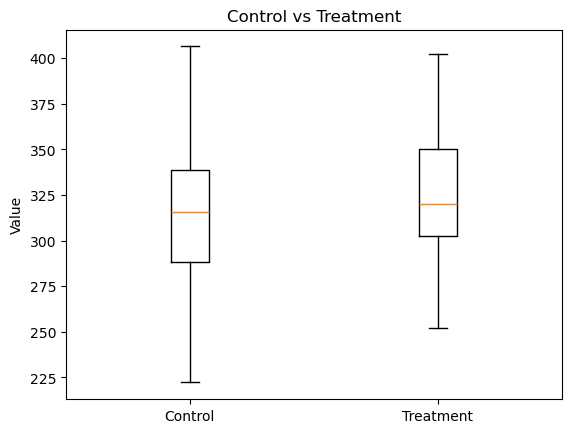

In [19]:
# TODO: Create at least ONE plot (boxplot or histogram) to compare groups.
# Tip: A boxplot is often a quick, clear comparison.

plt.boxplot([control, treatment], tick_labels=["Control", "Treatment"])
plt.ylabel("Value")
plt.title("Control vs Treatment")



## 7) Interpret and Document Results

### Results & Interpretation

- **Test used: independant sample T-test**  
- **t statistic: 1.36**  
- **p-value: 0.176**  
- **Decision (α = 0.05): alternative hypothysis is true**  
- **Plain-language conclusion: because the p-value is larger than 0.05, there is NO statistically significance between the two groups means**  

**Assumptions / limitations:**  
-  need MORE data, our sample size is very small
